# Question -

### Predicting taxi trip fare based on various factors

### Regression Task

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib as mpl 
import matplotlib.pyplot as plt 
import seaborn as sns 

np.random.seed(42)

# Get the data

In [2]:
import kaggle

# Download dataset to current folder
kaggle.api.dataset_download_files('denkuznetz/taxi-price-prediction', path='.', unzip=True)
print("Dataset downloaded and extracted to current folder.")

Dataset URL: https://www.kaggle.com/datasets/denkuznetz/taxi-price-prediction
Dataset downloaded and extracted to current folder.


In [3]:
taxi_prices = pd.read_csv("taxi_trip_pricing.csv")
taxi_prices.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


## Take a quick look at data

In [4]:
taxi_prices.shape

(1000, 11)

In [5]:
# know the attributes
taxi_prices.columns

Index(['Trip_Distance_km', 'Time_of_Day', 'Day_of_Week', 'Passenger_Count',
       'Traffic_Conditions', 'Weather', 'Base_Fare', 'Per_Km_Rate',
       'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price'],
      dtype='object')

### Attributes
- **Trip_Distance_km:** The distance of the trip in kilometers.
- **Time_of_Day:** The time when the trip started (morning, afternoon, evening, night).
- **Day_of_Week:** The day of the week the trip took place (Monday to Sunday).
- **Passenger_Count:** The number of passengers on the trip.
- **Traffic_Conditions:** The traffic situation during the trip (light, medium, heavy).
- **Weather:** The weather conditions during the trip (clear, rain, snow).
- **Base_Fare:** The fixed starting fare for the trip.
- **Per_Km_Rate:** The cost charged per kilometer traveled.
- **Per_Minute_Rate:** The cost charged per minute of travel.
- **Trip_Duration_Minutes:** The total duration of the trip in minutes.
- **Trip_Price (target):** The final fare amount for the trip in USD.

In [6]:
taxi_prices.head(10)

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
5,8.64,Afternoon,Weekend,2.0,Medium,Clear,2.55,1.71,0.48,89.33,60.2028
6,3.85,Afternoon,Weekday,4.0,High,Rain,3.51,1.66,NaN,5.05,11.2645
7,43.44,Evening,Weekend,3.0,NaN,Clear,2.97,1.87,0.23,NaN,101.1216
8,30.45,Morning,Weekday,3.0,High,Clear,2.77,1.78,0.34,110.33,NaN
9,35.70,Afternoon,Weekday,2.0,Low,Rain,3.39,1.52,0.47,NaN,75.5657


In [7]:
taxi_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [8]:
taxi_prices.describe()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,951.000000
mean,27.070547,2.476842,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,1.102249,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,1.250000,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,2.000000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,3.000000,4.260000,1.610000,0.390000,89.055000,69.099350
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


In [9]:
taxi_prices.isnull().sum()

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

In [10]:
taxi_prices.duplicated().sum()

0

# Discovering & Visualizing Data

## Visualize Data

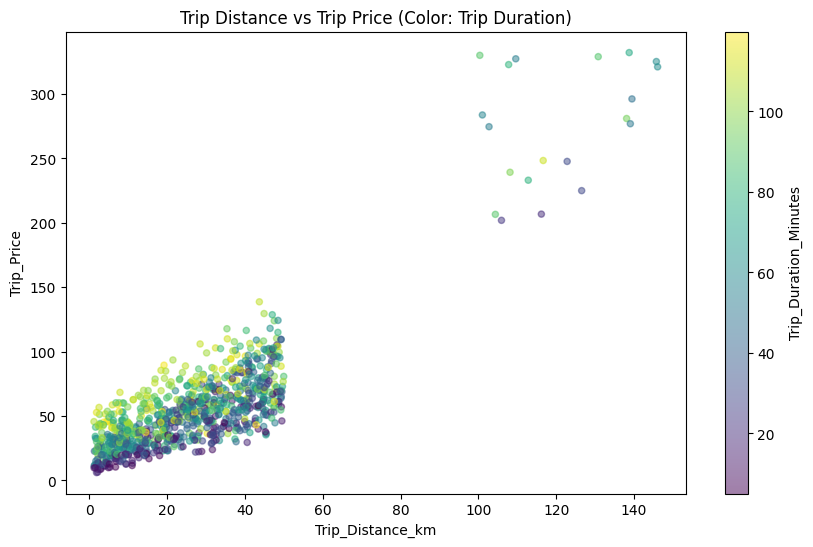

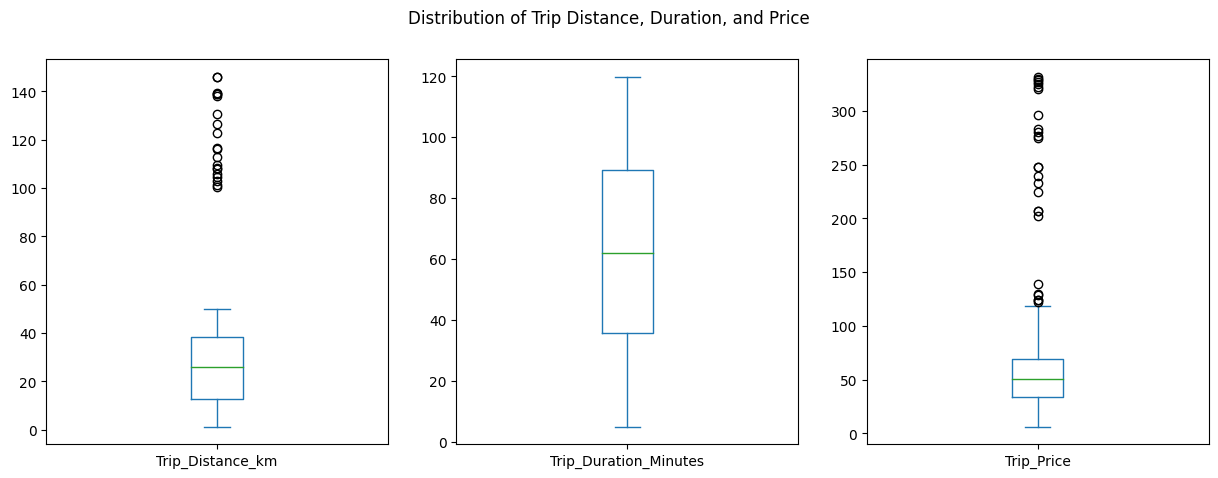

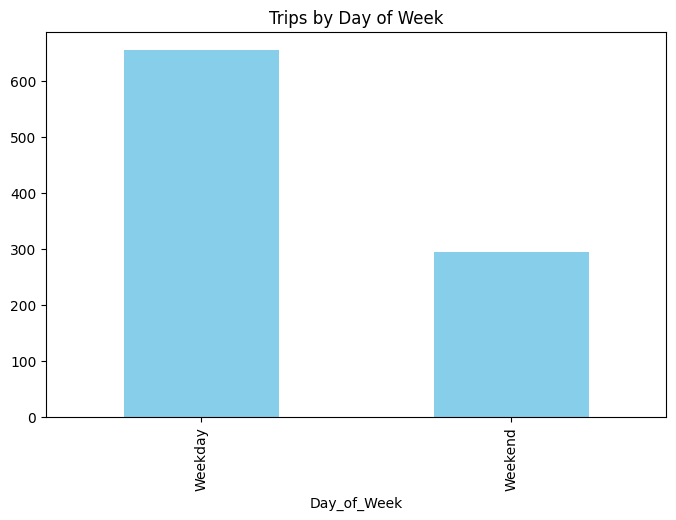

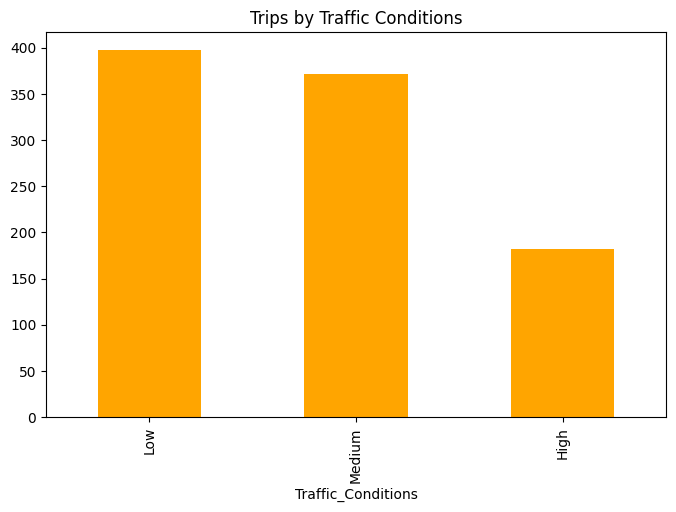

In [11]:
# Basic plotting of numerical attributes
taxi_prices.plot(kind='scatter', x='Trip_Distance_km', y='Trip_Price', alpha=0.5, c='Trip_Duration_Minutes', 
                 cmap='viridis', colorbar=True, figsize=(10, 6))
plt.title('Trip Distance vs Trip Price (Color: Trip Duration)')
plt.show()

# Plot distributions of key numerical features
taxi_prices[['Trip_Distance_km', 'Trip_Duration_Minutes', 'Trip_Price']].plot(kind='box', subplots=True, layout=(1, 3), figsize=(15, 5))
plt.suptitle('Distribution of Trip Distance, Duration, and Price')
plt.show()

# Count plots for categorical features
taxi_prices['Day_of_Week'].value_counts().plot(kind='bar', title='Trips by Day of Week', color='skyblue', figsize=(8, 5))
plt.show()
taxi_prices['Traffic_Conditions'].value_counts().plot(kind='bar', title='Trips by Traffic Conditions', color='orange', figsize=(8, 5))
plt.show()

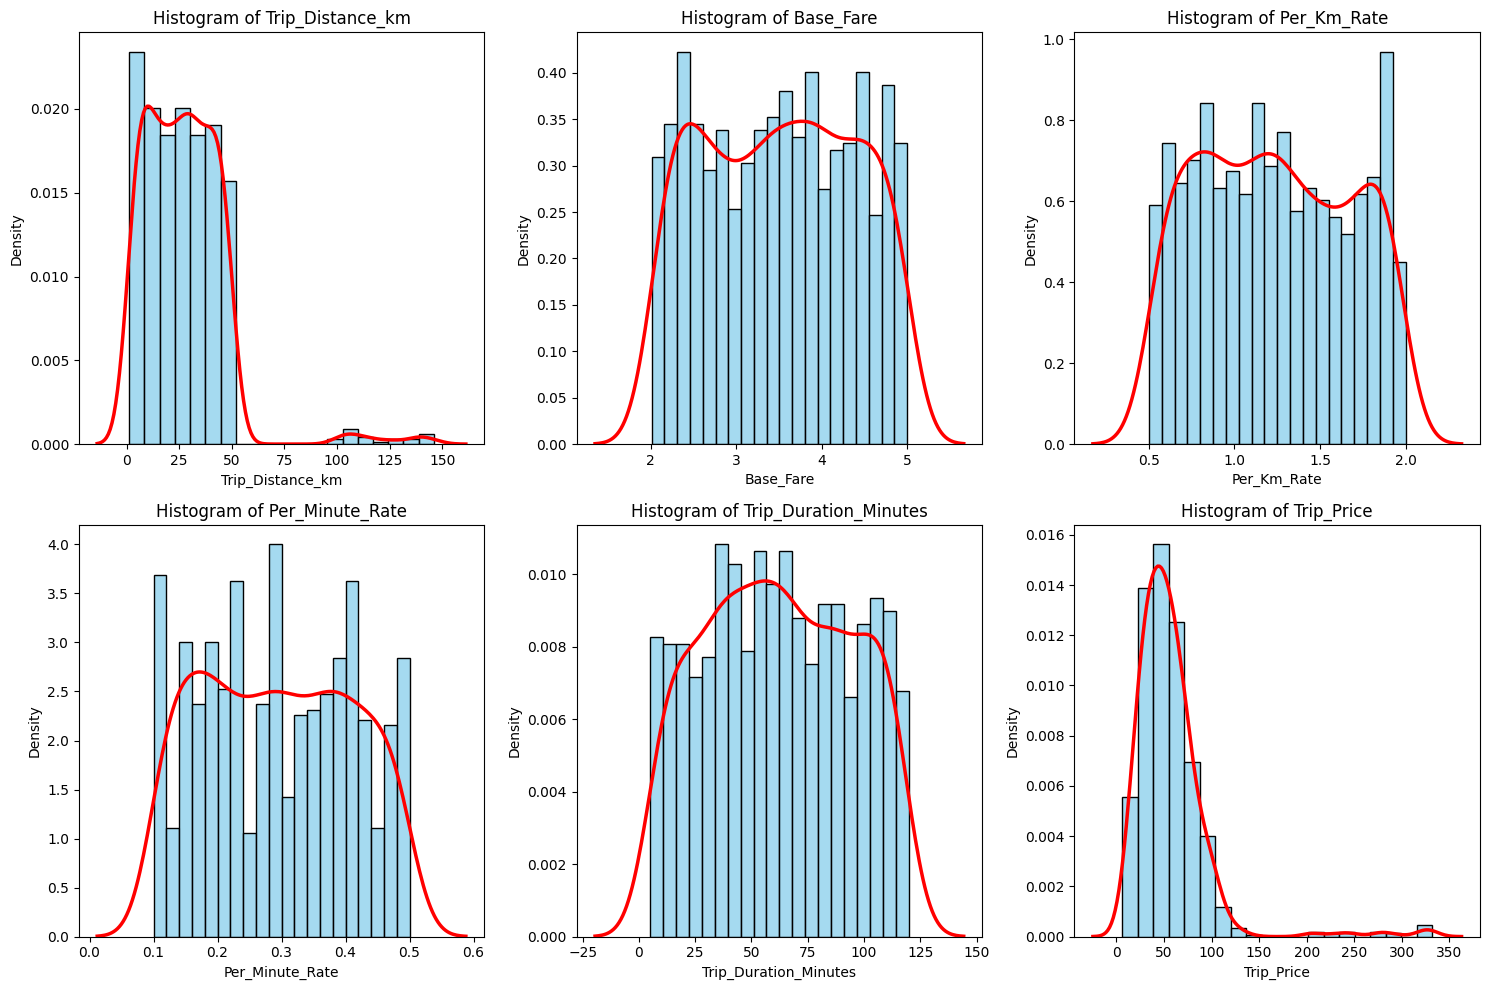

In [12]:
# Select numerical features
features = ['Trip_Distance_km', 'Base_Fare', 'Per_Km_Rate', 'Per_Minute_Rate', 
             'Trip_Duration_Minutes', 'Trip_Price']

# Plot histograms with KDE curves
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(taxi_prices[feature], bins=20, color='skyblue', stat='density')
    sns.kdeplot(taxi_prices[feature], color='red', linewidth=2.5)
    plt.title(f'Histogram of {feature}')

plt.tight_layout()
plt.show()

In [13]:
# we now know that they are not in bell shape
# we need to scale them to get proper results

## Look for correlations

In [14]:
# Numerical features
numerical_features = taxi_prices.select_dtypes(include=['float64', 'int64']).columns

# Find correlations
correlation_matrix = taxi_prices[numerical_features].corr()
correlation_matrix

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
Trip_Distance_km,1.000000,-0.048397,0.032218,-0.017041,-0.025902,-0.022102,0.849123
Passenger_Count,-0.048397,1.000000,0.022932,0.030213,0.034068,0.022845,-0.014223
Base_Fare,0.032218,0.022932,1.000000,0.003092,-0.019150,0.012035,0.035533
Per_Km_Rate,-0.017041,0.030213,0.003092,1.000000,0.029241,0.027199,0.275135
Per_Minute_Rate,-0.025902,0.034068,-0.019150,0.029241,1.000000,-0.024230,0.141226
Trip_Duration_Minutes,-0.022102,0.022845,0.012035,0.027199,-0.024230,1.000000,0.221211
Trip_Price,0.849123,-0.014223,0.035533,0.275135,0.141226,0.221211,1.000000


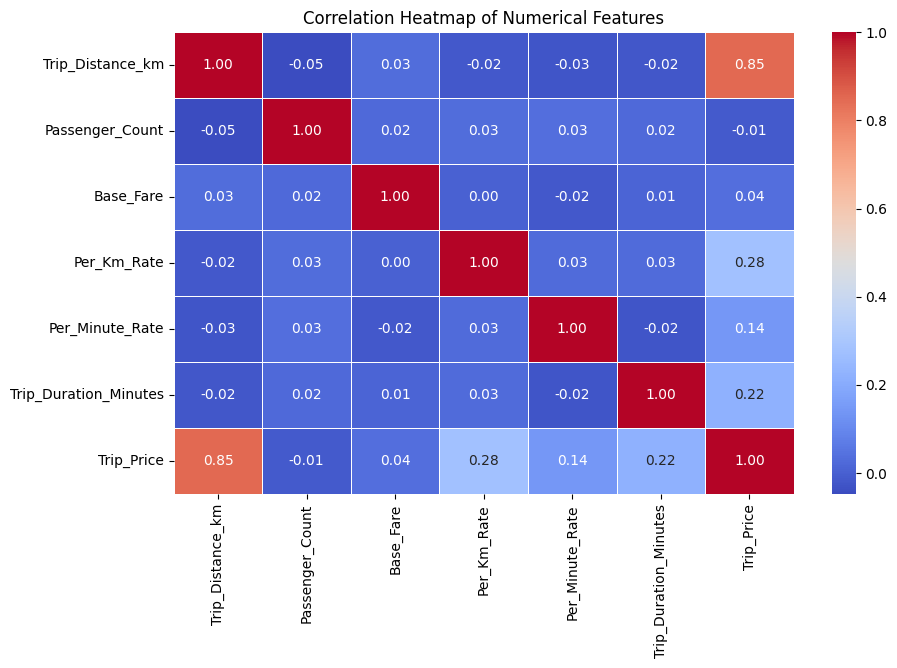

In [15]:
# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

C:\Users\ramch\AppData\Local\Temp\ipykernel_13220\2429591620.py:8: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


<Figure size 1500x1500 with 0 Axes>

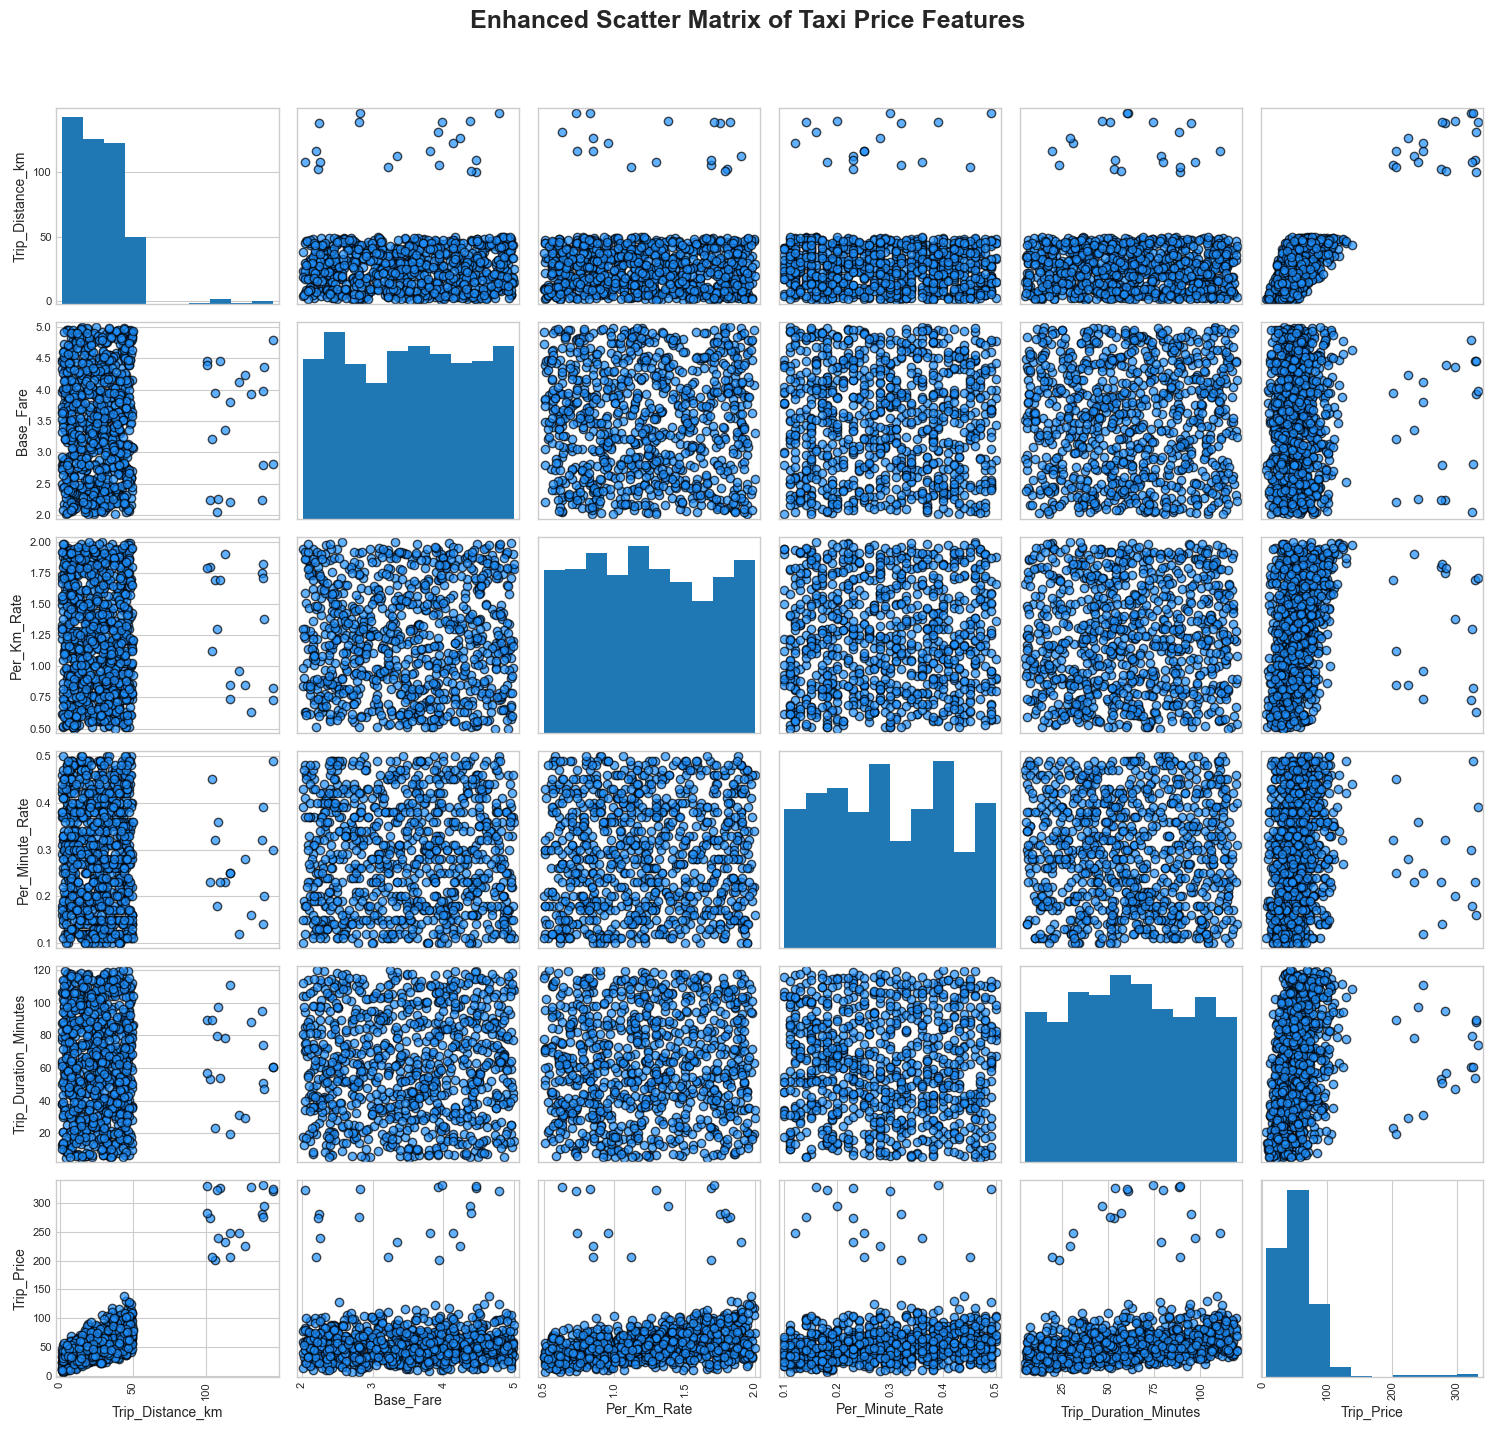

In [16]:
from pandas.plotting import scatter_matrix

# Select features for scatter matrix
features = ['Trip_Distance_km', 'Base_Fare', 'Per_Km_Rate', 'Per_Minute_Rate', 
             'Trip_Duration_Minutes', 'Trip_Price']


plt.style.use('seaborn-whitegrid')
plt.figure(figsize=(15, 15))

# Plot scatter matrix
scatter_matrix(taxi_prices[features], figsize=(15, 15), alpha=0.7, 
                color='dodgerblue', edgecolor='black', marker='o')

plt.suptitle('Enhanced Scatter Matrix of Taxi Price Features', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Experimenting with Attribute Combinations

In [17]:
# Create derived features
taxi_prices['Speed_km_per_min'] = taxi_prices['Trip_Distance_km'] / taxi_prices['Trip_Duration_Minutes']
taxi_prices['Distance_x_Duration'] = taxi_prices['Trip_Distance_km'] * taxi_prices['Trip_Duration_Minutes']

# Handle infinities
taxi_prices.replace([np.inf, -np.inf], np.nan, inplace=True)

# get correlation matrix
all_numerical_features = taxi_prices.select_dtypes(include=['float64', 'int64']).columns
full_correlation_matrix = taxi_prices[all_numerical_features].corr()

# Get correlations with Trip_Price and sort them
trip_price_corr = full_correlation_matrix['Trip_Price'].sort_values(ascending=False)
trip_price_corr

Trip_Price               1.000000
Trip_Distance_km         0.849123
Distance_x_Duration      0.789401
Per_Km_Rate              0.275135
Speed_km_per_min         0.236089
Trip_Duration_Minutes    0.221211
Per_Minute_Rate          0.141226
Base_Fare                0.035533
Passenger_Count         -0.014223
Name: Trip_Price, dtype: float64

In [29]:
# as extra attributes are more correlated we can use them

In [18]:
# Drop derived features
taxi_prices.drop(['Speed_km_per_min', 'Distance_x_Duration'], axis=1, inplace=True)

# Prepare Data for ML Algorithm

## Data Cleaning

In [ ]:
# check for duplicates
taxi_prices.duplicated().sum()

In [20]:
# check for missing values
taxi_prices.isnull().sum()

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

In [21]:
# fill missing values
from sklearn.impute import SimpleImputer

numerical_cols = ['Trip_Distance_km', 'Passenger_Count', 'Base_Fare', 
                  'Per_Km_Rate', 'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price']
categorical_cols = ['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather']

# Impute numerical columns with median
num_imputer = SimpleImputer(strategy='median')
taxi_prices[numerical_cols] = num_imputer.fit_transform(taxi_prices[numerical_cols])

# Impute categorical columns with most frequent value (mode)
cat_imputer = SimpleImputer(strategy='most_frequent')
taxi_prices[categorical_cols] = cat_imputer.fit_transform(taxi_prices[categorical_cols])

In [23]:
print(num_imputer.statistics_)
print(cat_imputer.statistics_)

[25.83    2.      3.52    1.22    0.29   61.86   50.0745]
['Afternoon' 'Weekday' 'Low' 'Clear']


In [24]:
taxi_prices.isnull().sum()

Trip_Distance_km         0
Time_of_Day              0
Day_of_Week              0
Passenger_Count          0
Traffic_Conditions       0
Weather                  0
Base_Fare                0
Per_Km_Rate              0
Per_Minute_Rate          0
Trip_Duration_Minutes    0
Trip_Price               0
dtype: int64

## Create Test set

In [26]:
X = taxi_prices.drop(['Trip_Price'], axis=1)
y = taxi_prices['Trip_Price']

In [27]:
# as no.of instances is low we use stratified sampling
from sklearn.model_selection import StratifiedShuffleSplit

# Stratified sampling based on 'Trip_Price' (binning for continuous values)
taxi_prices['Trip_Price_Bins'] = pd.qcut(taxi_prices['Trip_Price'], q=5, labels=False)

# Stratified split
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in split.split(X, taxi_prices['Trip_Price_Bins']):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Drop the temporary bin column
taxi_prices.drop('Trip_Price_Bins', axis=1, inplace=True)

In [28]:
print("Train set size:", X_train.shape)
print("Test set size:", X_test.shape)

Train set size: (800, 10)
Test set size: (200, 10)


## Pipeline and Handling Attributes

In [42]:
# Custom transformer to add extra attributes
from sklearn.base import BaseEstimator, TransformerMixin

class ExtraAttributesAdder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['Speed_km_per_min'] = X['Trip_Distance_km'] / X['Trip_Duration_Minutes']
        X['Distance_x_Duration'] = X['Trip_Distance_km'] * X['Trip_Duration_Minutes']
        X.replace([np.inf, -np.inf], np.nan, inplace=True)
        X.fillna(0, inplace=True)
        return X

In [47]:
# pieline for numerical attributes
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler

numerical_cols = ['Trip_Distance_km', 'Passenger_Count', 'Base_Fare', 
                  'Per_Km_Rate', 'Per_Minute_Rate', 'Trip_Duration_Minutes']
extra_num_attribs = ['Speed_km_per_min', 'Distance_x_Duration']

num_pipeline = Pipeline([
    ('extra_attributes', ExtraAttributesAdder()),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# we could now use imputer or use imputer first on 
# whole dataset and don't use it now

In [48]:
# pipeline for categorical attributes
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather']

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [49]:
# total transformer using column transformer
from sklearn.compose import ColumnTransformer

full_pipeline = ColumnTransformer([
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols)
])

In [50]:
X_train_prepared = full_pipeline.fit_transform(X_train)
X_test_prepared = full_pipeline.transform(X_test)

In [51]:
X_train_prepared.shape

(800, 20)

# Select & Train a Model

### Linear Model

In [52]:
# lets train SGDRegressor
from sklearn.linear_model import SGDRegressor

# Train the model
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)
sgd_reg.fit(X_train_prepared, y_train)


SGDRegressor(random_state=42)

In [53]:
from sklearn.metrics import mean_squared_error

# Predictions on training set
y_train_pred = sgd_reg.predict(X_train_prepared)
train_rmse = mean_squared_error(y_train, y_train_pred, squared=False)
print(f"Train RMSE: {train_rmse:.2f}")

Train RMSE: 15.77


In [54]:
from sklearn.model_selection import cross_val_score

# Cross-validation 
cv_scores = cross_val_score(sgd_reg, X_train_prepared, y_train, 
                            scoring='neg_root_mean_squared_error', cv=3)

# Convert negative RMSE scores to positive
cv_rmse_scores = -cv_scores
print("Cross-validation RMSE scores:", cv_rmse_scores)
print(f"Mean CV RMSE: {cv_rmse_scores.mean():.2f}")

Cross-validation RMSE scores: [16.44138574 13.82476149 18.94202753]
Mean CV RMSE: 16.40


In [55]:
# both are high the model is underfitting

### SVM

In [56]:
# lets train svm with rbf kernel
from sklearn.svm import SVR

svr_reg = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_reg.fit(X_train_prepared, y_train)

SVR()

In [57]:
# Predictions on training set
y_train_pred = svr_reg.predict(X_train_prepared)
train_rmse = mean_squared_error(y_train, y_train_pred, squared=False)
print(f"Train RMSE: {train_rmse:.2f}")

Train RMSE: 32.15


In [58]:
# Cross-validation 
cv_scores = cross_val_score(svr_reg, X_train_prepared, y_train, 
                            scoring='neg_root_mean_squared_error', cv=3)

# Convert negative RMSE scores to positive
cv_rmse_scores = -cv_scores
print("Cross-validation RMSE scores:", cv_rmse_scores)
print(f"Mean CV RMSE: {cv_rmse_scores.mean():.2f}")

Cross-validation RMSE scores: [34.66285169 22.857008   40.21567002]
Mean CV RMSE: 32.58


In [59]:
# svm model is also underfitting

### Decision Tree

In [60]:
# lets train a Decision Tree
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(max_depth=None, random_state=42)
tree_reg.fit(X_train_prepared, y_train)

DecisionTreeRegressor(random_state=42)

In [61]:
# Evaluating on training set
y_train_pred = tree_reg.predict(X_train_prepared)
train_rmse = mean_squared_error(y_train, y_train_pred, squared=False)
print(f"Train RMSE: {train_rmse:.2f}")

Train RMSE: 0.00


In [62]:
# Cross-validation
cv_scores = cross_val_score(tree_reg, X_train_prepared, y_train, 
                            scoring='neg_root_mean_squared_error', cv=3)

cv_rmse_scores = -cv_scores
print("Cross-validation RMSE scores:", cv_rmse_scores)
print(f"Mean CV RMSE: {cv_rmse_scores.mean():.2f}")

Cross-validation RMSE scores: [18.2963951  14.96492741 15.28430646]
Mean CV RMSE: 16.18


In [63]:
# Decision Tree is overfitting

In [85]:
# fine-tunning to reduce variance
from sklearn.model_selection import GridSearchCV

# Define hyperparameters for tuning
param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

tree_reg = DecisionTreeRegressor(random_state=42)
grid_search_dt = GridSearchCV(tree_reg, param_grid, 
                           scoring='neg_root_mean_squared_error', 
                           cv=3, n_jobs=-1, verbose=1)
grid_search_dt.fit(X_train_prepared, y_train)

Fitting 3 folds for each of 108 candidates, totalling 324 fits


GridSearchCV(cv=3, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, 20],
                         'max_features': ['sqrt', 'log2', None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [86]:
# Best hyperparameters and score
print("Best hyperparameters:", grid_search_dt.best_params_)
print(f"Best RMSE: {-grid_search_dt.best_score_:.2f}")

Best hyperparameters: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best RMSE: 14.42


In [87]:
# Evaluate the best model on the training set
best_tree_reg = grid_search_dt.best_estimator_
y_train_pred = best_tree_reg.predict(X_train_prepared)
train_rmse = mean_squared_error(y_train, y_train_pred, squared=False)
print(f"Train RMSE: {train_rmse:.2f}")

Train RMSE: 8.17


In [67]:
# it is still overfitts but now it is better

### Random Forest

In [88]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(random_state=42)

# Define hyperparameters for tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

grid_search_rf = GridSearchCV(rf_reg, param_grid, 
                           scoring='neg_root_mean_squared_error', 
                           cv=3, n_jobs=-1, verbose=1)
grid_search_rf.fit(X_train_prepared, y_train)

Fitting 3 folds for each of 162 candidates, totalling 486 fits


GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, 30],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [89]:
# Best hyperparameters and score
print("Best hyperparameters:", grid_search_rf.best_params_)
print(f"Best RMSE: {-grid_search_rf.best_score_:.2f}")

Best hyperparameters: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best RMSE: 15.83


In [90]:
# Evaluate on train set
best_rf_reg = grid_search_rf.best_estimator_
y_train_pred = best_rf_reg.predict(X_train_prepared)
train_rmse = mean_squared_error(y_train, y_train_pred, squared=False)
print(f"Train RMSE: {train_rmse:.2f}")

Train RMSE: 5.45


In [71]:
# random forest is more overfitting than Decision Tree

### XGBoost

In [92]:
from xgboost import XGBRegressor

xgb_reg = XGBRegressor(objective='reg:squarederror', random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

grid_search_xgb = GridSearchCV(xgb_reg, param_grid, 
                           scoring='neg_root_mean_squared_error', 
                           cv=3, n_jobs=-1, verbose=1)
grid_search_xgb.fit(X_train_prepared, y_train)

Fitting 3 folds for each of 243 candidates, totalling 729 fits


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=42, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.8, 1.0],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.7, 0.8, 1.0]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [93]:
# Best hyperparameters and score
print("Best hyperparameters:", grid_search_xgb.best_params_)
print(f"Best RMSE: {-grid_search.best_score_:.2f}")

Best hyperparameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best RMSE: 12.63


In [94]:
# Evaluate on train set
best_xgb_reg = grid_search_xgb.best_estimator_
y_train_pred = best_xgb_reg.predict(X_train_prepared)
train_rmse = mean_squared_error(y_train, y_train_pred, squared=False)
print(f"Train RMSE: {train_rmse:.2f}")

Train RMSE: 6.29


In [75]:
# XGBoost has better result than RandomForest and Decision Tree
# but it still overfitts

In [76]:
# fine-tunning further
param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'reg_alpha': [0.01, 0.1, 1],
    'reg_lambda': [0.1, 1, 10]
}

grid_search = GridSearchCV(xgb_reg, param_grid,
                           scoring='neg_root_mean_squared_error',
                           cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train_prepared, y_train)

Fitting 5 folds for each of 1458 candidates, totalling 7290 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=42, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.6, 0.7, 0.8],
                         'learning_rate': [0.05, 0.1], 'max_depth': [2, 3, 4],
                         'n_estimators': [200, 300, 400],
                         'reg_alpha': [0.01, 0.1, 1],
                         'reg_lambda': [0.1, 1, 10],
                         'subsample': [0.6, 0.7, 0.8]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [77]:
# Best hyperparameters and score
print("Best hyperparameters:", grid_search.best_params_)
print(f"Best RMSE: {-grid_search.best_score_:.2f}")

Best hyperparameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 400, 'reg_alpha': 1, 'reg_lambda': 10, 'subsample': 0.8}
Best RMSE: 12.63


In [78]:
# Evaluate on train set
best_xgb_reg = grid_search.best_estimator_
y_train_pred = best_xgb_reg.predict(X_train_prepared)
train_rmse = mean_squared_error(y_train, y_train_pred, squared=False)
print(f"Train RMSE: {train_rmse:.2f}")

Train RMSE: 6.63


# Fine-Tuning and Ensemble Methods

In [97]:
# Voting regressor
from sklearn.ensemble import VotingRegressor

ensemble_model = VotingRegressor(estimators=[
    ('dt', best_tree_reg),
    ('rf', best_rf_reg),
    ('xgb', best_xgb_reg)
])
ensemble_model.fit(X_train_prepared, y_train)

VotingRegressor(estimators=[('dt',
                             DecisionTreeRegressor(max_depth=10,
                                                   min_samples_leaf=4,
                                                   min_samples_split=10,
                                                   random_state=42)),
                            ('rf',
                             RandomForestRegressor(max_depth=30,
                                                   max_features='sqrt',
                                                   random_state=42)),
                            ('xgb',
                             XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=1.0, device=None,
                                          ea...
                                          gamma=None, grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=0.1, max_bin=None,
                                          max_cat_threshold=None,
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=3,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None, n_estimators=100,
                                          n_jobs=None, num_parallel_tree=None,
                                          random_state=42, ...))])

In [98]:
# Train set evaluation
y_train_pred = ensemble_model.predict(X_train_prepared)
train_rmse = mean_squared_error(y_train, y_train_pred, squared=False)
print(f'Train RMSE: {train_rmse:.2f}')

Train RMSE: 5.35


In [ ]:
# Cross-validation
cv_scores = cross_val_score(ensemble_model, X_train_prepared, y_train, 
                            scoring='neg_root_mean_squared_error', cv=5)

cv_rmse_scores = -cv_scores
print(f'Cross-Validation RMSE Scores: {cv_rmse_scores}')
print(f'Average CV RMSE: {cv_rmse_scores.mean():.2f}')

Cross-Validation RMSE Scores: [12.52556564 13.44747437 10.11786701 11.55237746 16.5796764 ]
Average CV RMSE: 12.84


In [100]:
# we got good estimate we can further fine-tune models
# but it is suffient for now

# Evaluate on test set

In [102]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_test_pred = ensemble_model.predict(X_test_prepared)

rmse = mean_squared_error(y_test, y_test_pred, squared=False)
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print(f'Test RMSE: {rmse:.2f}')
print(f'Test MAE: {mae:.2f}')
print(f'Test R² Score: {r2:.2f}')

Test RMSE: 10.73
Test MAE: 6.87
Test R² Score: 0.94


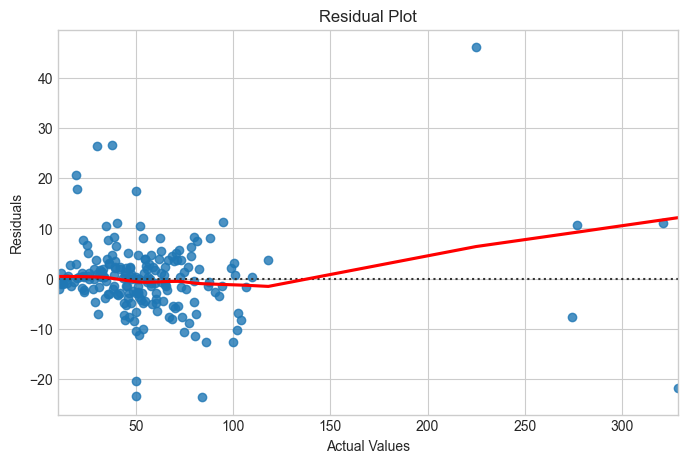

In [105]:
# residual plot
plt.figure(figsize=(8, 5))
sns.residplot(x=y_test, y=y_test_pred, lowess=True, line_kws={'color': 'red'})
plt.xlabel('Actual Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

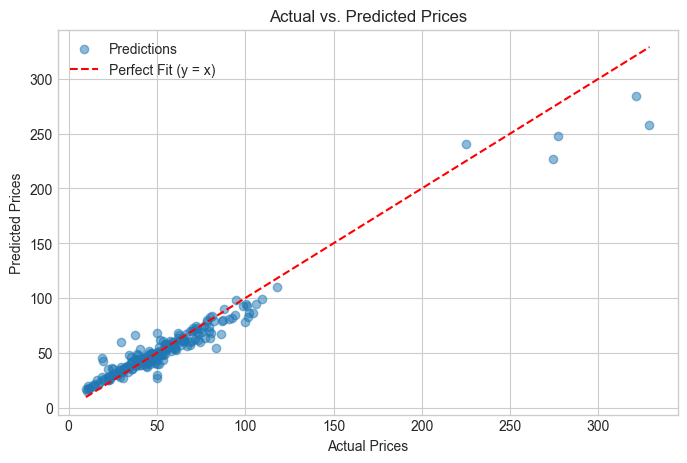

In [108]:
# actual vs predicted values
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_test_pred, alpha=0.5, label='Predictions')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Perfect Fit (y = x)')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs. Predicted Prices')
plt.legend()
plt.show()